# T03 — Advection, and the diffusion you did not ask for

**Cluster B — The numerical ladder.**

Diffusion is forgiving. Advection is not. This notebook takes one initial
condition, moves it once around a periodic domain with four different schemes,
and shows that the results look nothing like each other.

The equation could hardly be simpler:

$$\frac{\partial C}{\partial t} + v\frac{\partial C}{\partial x} = 0$$

The exact solution is the initial condition, translated. Anything else your code
produces is error — which makes this the cleanest possible diagnostic.

## Learning objectives

1. Define the Courant number and explain what it controls.
2. Distinguish **stability**, **accuracy** and **monotonicity** — three different things.
3. Recognise numerical diffusion and numerical dispersion on sight.
4. Explain why real geodynamic codes use semi-Lagrangian advection or markers.

## Prerequisites and runtime

* T01. NumPy.
* **Estimated runtime: under 20 seconds.**

In [1]:
# === USER CONFIGURATION ===
NX = 200
VELOCITY = 1.0
N_REVOLUTIONS = 1.0
CFL_STABLE = 0.5
CFL_LARGE = 3.0

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from geodynkit.advection import SCHEMES, advect_1d, courant_dt

L = 1.0
dx = L / NX
x = np.arange(NX) * dx

square = np.where(np.abs(x - 0.3) < 0.1, 1.0, 0.0)
gaussian = np.exp(-((x - 0.7) ** 2) / 0.005)
C0 = square + gaussian     # a sharp front AND a smooth bump, to probe both failure modes

## 1. The Courant number

$$\mathrm{Co} = \frac{v\,\Delta t}{\Delta x}$$

It is the number of cells a parcel crosses in one timestep. Explicit schemes
generally require $\mathrm{Co} \le 1$: information must not outrun the stencil.

In [3]:
dt = courant_dt(VELOCITY, dx, cfl=CFL_STABLE)
nsteps = int(N_REVOLUTIONS * L / (VELOCITY * dt))
print(f"Co = {CFL_STABLE},  dt = {dt:.5f},  {nsteps} steps for "
      f"{N_REVOLUTIONS:g} revolution(s)")
print("After exactly one revolution the exact answer is the initial condition.")

Co = 0.5,  dt = 0.00250,  400 steps for 1 revolution(s)
After exactly one revolution the exact answer is the initial condition.


## 2. Four schemes, one revolution

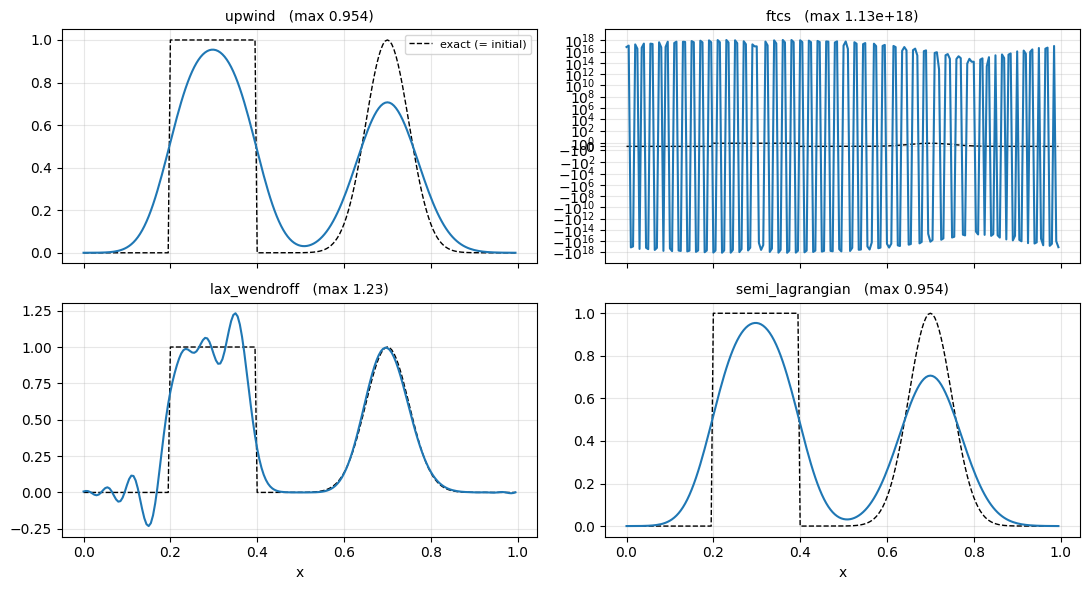

In [4]:
results = {s: advect_1d(C0, VELOCITY, dx, dt, nsteps, scheme=s)[-1] for s in SCHEMES}

fig, ax = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for a, s in zip(ax.ravel(), SCHEMES):
    a.plot(x, C0, "k--", lw=1, label="exact (= initial)")
    a.plot(x, results[s], "C0", lw=1.5)
    a.set_title(f"{s}   (max {results[s].max():.3g})", fontsize=10)
    a.grid(alpha=0.3)
    if s == "ftcs":
        a.set_yscale("symlog")
for a in ax[1]:
    a.set_xlabel("x")
ax[0, 0].legend(fontsize=8)
fig.tight_layout()
plt.show()

Read those four panels carefully, because each fails differently.

**FTCS** is second-order accurate in space and **unconditionally unstable** for
pure advection. It has grown by many orders of magnitude — note the log axis.
This is the cleanest demonstration in the suite that *accuracy and stability are
independent properties*. A scheme can be more accurate and completely useless.

**Upwind** survives, and is **monotone**: no value appears that was not already
in the initial condition. It pays for that with heavy **numerical diffusion** —
the square wave has rounded off and the Gaussian has lost amplitude. Nobody
asked for diffusion; it is an artefact of the discretisation, and it is
indistinguishable in the output from real physical diffusion.

**Lax–Wendroff** is second order and keeps the amplitude far better, but it is
**dispersive**: different wavelengths travel at slightly different speeds, so
ripples appear behind the sharp front, including undershoots below zero. For a
concentration or a temperature that can be physically impossible.

**Semi-Lagrangian** traces the characteristic backwards and interpolates.

In [5]:
print(f"{'scheme':>16} {'peak':>9} {'min':>9} {'mass err %':>11}")
m0 = C0.sum()
for s in SCHEMES:
    r = results[s]
    print(f"{s:>16} {r.max():9.4f} {r.min():9.4f} {100 * (r.sum() / m0 - 1):11.3f}")

          scheme      peak       min  mass err %
          upwind    0.9544    0.0001       0.000
            ftcs 1128677694810520832.0000 -1136533369770806784.0000      -1.639
    lax_wendroff    1.2321   -0.2313       0.000
 semi_lagrangian    0.9544    0.0001       0.000


## 3. A fact worth pausing on

Compare upwind and semi-Lagrangian in the table above. They are **identical**.

That is not a bug. With linear interpolation and $\mathrm{Co} \le 1$, the
semi-Lagrangian departure point lies less than one cell upstream, so the
interpolation weights *are* the upwind coefficients. The two schemes are the
same scheme in this regime.

In [6]:
diff = np.abs(results["upwind"] - results["semi_lagrangian"]).max()
print(f"max |upwind - semi_lagrangian| at Co = {CFL_STABLE}: {diff:.3e}")

max |upwind - semi_lagrangian| at Co = 0.5: 8.149e-14


## 4. Above Courant 1 they part company

Here is why real codes bother with semi-Lagrangian advection: it has **no
Courant restriction at all**. Tracing a characteristic backwards is valid
however far back it goes.

At Co = 3.0, after 66 steps:
            upwind: max |C| =    6.812e+44   DESTROYED
      lax_wendroff: max |C| =    5.642e+79   DESTROYED
   semi_lagrangian: max |C| =            1   stable


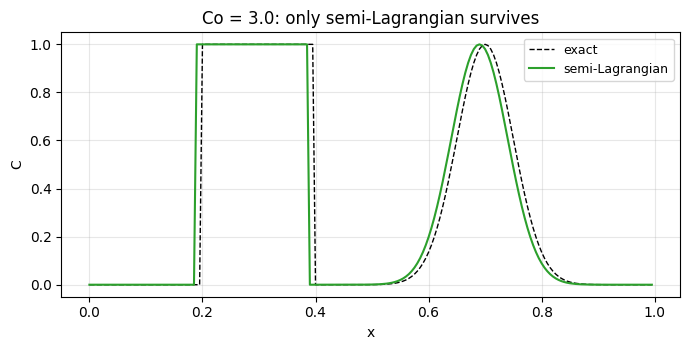

In [7]:
dt_big = courant_dt(VELOCITY, dx, cfl=CFL_LARGE)
nsteps_big = int(N_REVOLUTIONS * L / (VELOCITY * dt_big))
big = {s: advect_1d(C0, VELOCITY, dx, dt_big, nsteps_big, scheme=s) [-1]
       for s in ("upwind", "lax_wendroff", "semi_lagrangian")}

print(f"At Co = {CFL_LARGE}, after {nsteps_big} steps:")
for s, r in big.items():
    state = "stable" if np.abs(r).max() < 10 else "DESTROYED"
    print(f"  {s:>16}: max |C| = {np.abs(r).max():12.4g}   {state}")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(x, C0, "k--", lw=1, label="exact")
ax.plot(x, big["semi_lagrangian"], "C2", lw=1.5, label="semi-Lagrangian")
ax.set(xlabel="x", ylabel="C", title=f"Co = {CFL_LARGE}: only semi-Lagrangian survives")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Numerical diffusion is a real number

Upwind's smearing is not vague sloppiness — it is equivalent to adding a
physical diffusivity

$$\kappa_{\text{num}} = \frac{v\,\Delta x}{2}\left(1 - \mathrm{Co}\right)$$

Two consequences worth internalising. It **vanishes at Co = 1** (the scheme
becomes exact translation). And it is proportional to $\Delta x$, so the only
way to reduce it is to refine the grid — which is expensive, and is why the next
notebook abandons grid-based advection for materials altogether.

In [8]:
print(f"{'Co':>6} {'peak retained':>15} {'kappa_num':>12}")
for cfl in (0.1, 0.25, 0.5, 0.75, 0.9, 1.0):
    d = courant_dt(VELOCITY, dx, cfl=cfl)
    n = int(L / (VELOCITY * d))
    r = advect_1d(C0, VELOCITY, dx, d, n, scheme="upwind")[-1]
    kappa_num = VELOCITY * dx / 2 * (1 - cfl)
    print(f"{cfl:6.2f} {r.max() / C0.max():15.4f} {kappa_num:12.3e}")

    Co   peak retained    kappa_num
  0.10          0.8640    2.250e-03


  0.25          0.8974    1.875e-03
  0.50          0.9544    1.250e-03
  0.75          0.9954    6.250e-04
  0.90          1.0000    2.500e-04
  1.00          1.0000    0.000e+00


## Extend this

* Verify the $\kappa_{\text{num}}$ formula quantitatively: fit a Gaussian to the
  advected bump and compare its widening against $\sqrt{4\kappa_{\text{num}}t}$
  from T01.
* Implement a flux-limited scheme (van Leer or superbee) and show it is both
  second order in smooth regions *and* monotone at the front.
* Advect the square wave for ten revolutions instead of one. Does the error grow
  linearly with time?

**Next:** T04 introduces the Stokes solver — the piece that generates the
velocity field we have so far just assumed.